#  ToxiTube — YouTube Comment Toxicity Detector
## Notebook 01 — Exploration des données
**Dataset :** Jigsaw Toxic Comment Classification Challenge (Kaggle, ~160k commentaires Wikipedia)

**Objectif de ce notebook :**
- Charger et inspecter le dataset brut
- Comprendre la structure et la distribution des labels
- Créer le label binaire `is_toxic`
- Sauvegarder un checkpoint pour le notebook suivant

### Partie A — Imports & configuration

**Pourquoi ces imports ?**
- `pandas` / `numpy` : manipulation des données tabulaires
- `matplotlib` / `seaborn` : visualisations statiques
- `warnings` : on supprime les warnings non critiques pour garder un output propre

In [4]:
import sys
print(sys.executable)

c:\Users\nasri\OneDrive\Desktop\Projects\ToxiTube\toxitube_env\Scripts\python.exe


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8')
os.makedirs('../figures', exist_ok=True)
os.makedirs('../data/checkpoints', exist_ok=True)

print(' Imports OK')
print(f'Pandas  : {pd.__version__}')
print(f'Numpy   : {np.__version__}')

 Imports OK
Pandas  : 3.0.2
Numpy   : 2.4.4


### Partie B — Chargement des données

**Pourquoi ce dataset ?**
Le dataset Jigsaw contient ~160k commentaires Wikipedia annotés manuellement
par des évaluateurs humains selon 6 catégories de toxicité.
C'est la référence standard en NLP pour la détection de contenu haineux.

In [16]:
df = pd.read_csv('../data/train.csv')

print(f'Shape   : {df.shape}')
print(f'\nColonnes : {list(df.columns)}')
print(f'\nValeurs nulles :\n{df.isnull().sum()}')

Shape   : (159571, 8)

Colonnes : ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']

Valeurs nulles :
id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64


**Aperçu des premières lignes**

On inspecte les 3 premières lignes pour comprendre la structure :
- `id` : identifiant unique
- `comment_text` : le texte brut du commentaire
- 6 colonnes binaires (0/1) : les labels de toxicité

In [23]:
df.head(3)

,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my username Hardcore Metallica Fan were reverted? They wer...,0,0,0,0,0,0
1,000103f0d9cfb60f,"D'aww! He matches this background colour I'm seemingly stuck with. Thanks. (talk) 21:51, Januar...",0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It's just that this guy is constantly removing relev...",0,0,0,0,0,0


**Création du label binaire `is_toxic`**

**Pourquoi un label binaire ?**
On simplifie la tâche en classification binaire (toxique / normal).
Un commentaire est toxique si AU MOINS UN des 6 labels est à 1.
On utilise `max(axis=1)` qui retourne 1 dès qu'il y a un 1 dans la ligne.

Cette simplification est justifiée car :
- Elle rend le problème plus accessible pour un premier modèle
- Les 6 catégories sont fortement corrélées entre elles
- Elle permet une comparaison claire entre tous nos modèles

In [29]:
label_cols = ['toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']
df['is_toxic'] = df[label_cols].max(axis=1)

print(f'Commentaires normaux  : {(df["is_toxic"]==0).sum():,}')
print(f'Commentaires toxiques : {(df["is_toxic"]==1).sum():,}')
print(f'\nTaux de toxicité : {df["is_toxic"].mean()*100:.1f}%')

Commentaires normaux  : 143,346
Commentaires toxiques : 16,225

Taux de toxicité : 10.2%


**Visualisation de la distribution des classes**

**Pourquoi visualiser ?**
Le déséquilibre de classes (~90% normal / ~10% toxique) est un problème
majeur en Machine Learning. Si on l'ignore, le modèle apprend à tout
prédire "normal" et atteint 90% d'accuracy sans rien détecter.

Cette visualisation motive l'utilisation de :
- `class_weight='balanced'` dans nos modèles
- Le F1-macro comme métrique principale (et non l'accuracy)

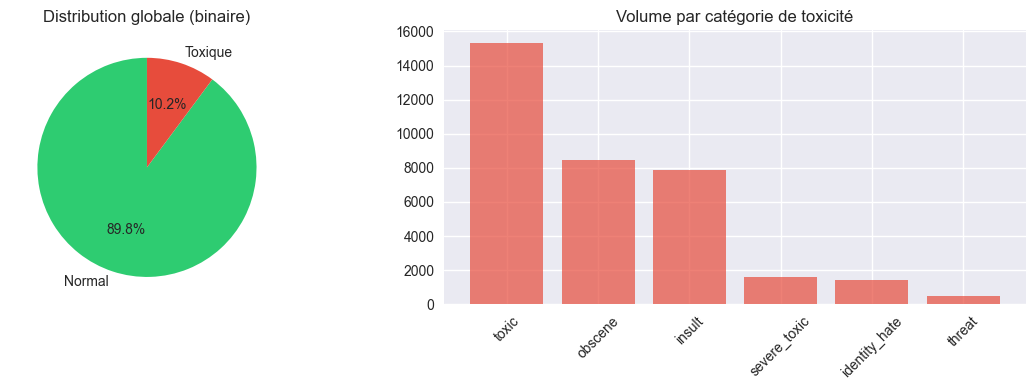

 Figure sauvegardée → figures/class_distribution.png


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = df['is_toxic'].value_counts()
axes[0].pie(counts, labels=['Normal', 'Toxique'], autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0].set_title('Distribution globale (binaire)')

sub_counts = df[label_cols].sum().sort_values(ascending=False)
axes[1].bar(sub_counts.index, sub_counts.values, color='#e74c3c', alpha=0.7)
axes[1].set_title('Volume par catégorie de toxicité')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../figures/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Figure sauvegardée → figures/class_distribution.png')

**Analyse de la longueur des commentaires**

**Pourquoi analyser la longueur ?**
La longueur des textes influence directement nos choix techniques :
- BERT a une limite de 512 tokens → les textes très longs seront tronqués
- TF-IDF traite les textes longs différemment des courts
- Une différence de longueur entre classes toxiques/normales est un signal utile

Statistiques de longueur par classe :
             count   mean    std  min    25%    50%    75%     max
is_toxic                                                          
0         143346.0  404.3  586.5  6.0  102.0  216.0  452.0  5000.0
1          16225.0  303.3  619.4  8.0   61.0  128.0  283.0  5000.0


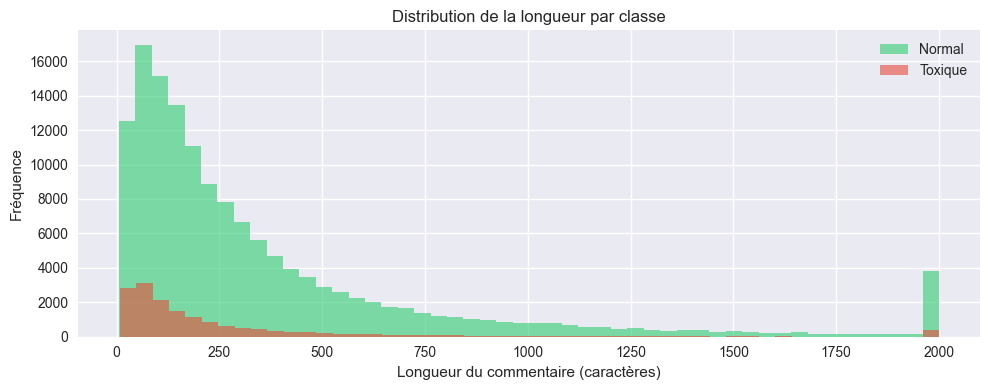

In [38]:
df['text_length'] = df['comment_text'].str.len()

print('Statistiques de longueur par classe :')
print(df.groupby('is_toxic')['text_length'].describe().round(1))

plt.figure(figsize=(10, 4))
df[df['is_toxic']==0]['text_length'].clip(upper=2000).hist(
    bins=50, alpha=0.6, label='Normal', color='#2ecc71')
df[df['is_toxic']==1]['text_length'].clip(upper=2000).hist(
    bins=50, alpha=0.6, label='Toxique', color='#e74c3c')
plt.xlabel('Longueur du commentaire (caractères)')
plt.ylabel('Fréquence')
plt.title('Distribution de la longueur par classe')
plt.legend()
plt.tight_layout()
plt.savefig('../figures/length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Exemples de commentaires**

Inspecter des exemples réels est indispensable avant de modéliser.
Cela permet de :
- Comprendre le type de langage utilisé
- Identifier les cas difficiles (sarcasme, argot, insultes implicites)
- Valider que les labels humains sont cohérents

In [41]:
print('=== 5 commentaires TOXIQUES ===\n')
for i, row in df[df['is_toxic']==1].sample(5, random_state=42).iterrows():
    print(f'[{i}] {row["comment_text"][:200]}')
    print()

print('=== 5 commentaires NORMAUX ===\n')
for i, row in df[df['is_toxic']==0].sample(5, random_state=42).iterrows():
    print(f'[{i}] {row["comment_text"][:200]}')
    print()

=== 5 commentaires TOXIQUES ===

[45045] "
I was talking about them running any check they want on ME to disprove your claims.  I didn't know where you lived until you were silly enough to post an IP and connect your name to it. And yes you 

[27198] White Trash
Fuck off you white piece of trash. Fucking wiggers. Go and fuck a Jew, Jew raper.

[16664] eat shit get rid of goofs you queers.

[8158] DUMB ASSES
It's was my sockpuppet...joe hazeton... you guys are out of control..... i am making a folder which will be submited to higher athority, one above the GOD KING JIMBO.... I WOULD STRONGLY SU

[142212] Are all professors of rhetoric pompous, self-centered assholes?  Or is it just you?

=== 5 commentaires NORMAUX ===

[46733] "

Oh, don't worry about me, Sandstein. I'm of no strong opinion as to what is ""well."" Editing Wikipedia is not a personal benefit; if it were, I'd be COI! I do have some unfinished business, both w

[110326] Are you trying to dispute that fact?

[76687] SWOT an

### Sauvegarde du checkpoint

**Pourquoi sauvegarder ?**
Les notebooks sont indépendants — les variables ne se transfèrent pas.
On sauvegarde `df` au format Parquet (plus rapide et léger que CSV)
pour que `02_preprocessing.ipynb` puisse le recharger directement.

In [45]:
import os
os.makedirs('../data/checkpoints', exist_ok=True)

# Sauvegarde en CSV (plus compatible que parquet)
df.to_csv('../data/checkpoints/df_after_exploration.csv', index=False)

print(' Checkpoint sauvegardé → data/checkpoints/df_after_exploration.csv')
print(f'   Shape : {df.shape}')
print(f'   Colonnes : {list(df.columns)}')

 Checkpoint sauvegardé → data/checkpoints/df_after_exploration.csv
   Shape : (159571, 10)
   Colonnes : ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate', 'is_toxic', 'text_length']


###  Bilan Notebook 01

| Élément | Valeur |
|---------|--------|
| Commentaires totaux | 159,571 |
| Commentaires normaux | ~143,346 (~90%) |
| Commentaires toxiques | ~16,225 (~10%) |
| Valeurs nulles | 0 |
| Colonnes créées | `is_toxic`, `text_length` |

**Point clé :** Le déséquilibre 90/10 impose d'utiliser le **F1-macro** comme métrique principale.

**Prochain notebook :** `02_preprocessing.ipynb` — nettoyage du texte + vectorisation TF-IDF et FastText.